# Phase III: First ML Proof of Concept (5\%)

### Team Names:
- William Hon
- Kinsey Bellerose
- Zaid Jilla
- Ved Deshpande

Two datasets were collected, one for individual Premier League game performance and one for news articles (from The Guardian API) about the specific team. The goal was to see if the number of articles written about a team prior to a game affected the team's performace.

**Note:** For phase 3 we realized the Twitter data we originally used was being rate limited, so we pivoted to Guardian articles. We also realized with SofaScore it was difficult to get individual team statistics so we pivoted to ESPN. Since much of Phase 2 had to be updated we included all the new data scraping and cleaning below. 

In [1]:
import requests
import pandas as pd
from datetime import datetime
import time
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options

## News Article Scraping

Using The Guardian API, we were able to search for news articles in a specific date range that were about the specific Premier League teams.

In [2]:
season_start = '2024-08-16'
season_end = '2026-05-25'
teams = ['Arsenal', 'Manchester City', 'Manchester United', 'Chelsea', 'Liverpool']
API_KEY = "001fa633-fc31-4e53-a402-9dfcf5c25c70"

In [3]:
def get_article_data(article, team):
    """Format specific article json response"""
    fields = article.get('fields', {})
    article_info = {
        'team': team,
        'title': article.get('webTitle', ''),
        'description': fields.get('trailText', ''),
        'headline': fields.get('headline', ''),
        'author': fields.get('byline', ''),
        'wordcount': fields.get('wordcount', ''),
        'published_at': article.get('webPublicationDate', ''),
        'url': article.get('webUrl', ''),
        'section': article.get('sectionName', ''),
        'content_type': article.get('type', ''),
    }
    return article_info

def get_guardian_articles(team, from_date, to_date, api_key, page_size):
    """Retrieves articles from The Guardian for a specific team"""
    url = "https://content.guardianapis.com/search"
    params = {
        'q': f'"{team}" Premier League',
        'from-date': from_date,
        'to-date': to_date,
        'api-key': api_key,
        'page-size': page_size,
        'show-fields': 'headline,trailText,byline,wordcount',
        'show-tags': 'keyword',
    }
    response = requests.get(url, params=params)
    data = response.json()
    articles_data = []
    
    if 'results' in data['response']:
        for article in data['response']['results']:
            article_info = get_article_data(article, team)
            articles_data.append(article_info)
    
    return pd.DataFrame(articles_data)

def get_all_teams_guardian_news(api_key, season_start, season_end, page_size):
    """Retrieve news data for five Premier League teams"""
    teams = ['Arsenal', 'Manchester City', 'Manchester United', 'Chelsea', 'Liverpool']
    all_articles = []
    
    for team in teams:
        team_df = get_guardian_articles(team, season_start, season_end, api_key, page_size)
        all_articles.append(team_df)
    
    return pd.concat(all_articles, ignore_index=True)

In [4]:
# Data for 2024 season
all_news_df = get_all_teams_guardian_news(
    api_key=API_KEY,
    season_start=season_start,
    season_end=season_end,
    page_size=100
)
all_news_df.head()

,team,title,description,headline,author,wordcount,published_at,url,section,content_type
0,Arsenal,Arsenal 4-1 Tottenham: Premier League – as it ...,A hat-trick from Eberechi Eze helped Arsenal d...,Arsenal 4-1 Tottenham: Premier League – as it ...,Daniel Harris,4270,2025-11-23T18:48:16Z,https://www.theguardian.com/football/live/2025...,Football,liveblog
1,Arsenal,Sunderland 2-2 Arsenal: Premier League – as it...,<strong>Minute-by-minute report:</strong> Afte...,Sunderland 2-2 Arsenal: Premier League – as it...,Scott Murray,4409,2025-11-08T20:13:30Z,https://www.theguardian.com/football/live/2025...,Football,liveblog
2,Arsenal,Fulham 0-1 Arsenal: Premier League – as it hap...,Minute-by-minute report: Another goal from a c...,Fulham 0-1 Arsenal: Premier League – as it hap...,Scott Murray,4221,2025-10-18T19:18:47Z,https://www.theguardian.com/football/live/2025...,Football,liveblog
3,Arsenal,Newcastle 1-2 Arsenal: Premier League – as it ...,Arsenal moved up to second after late headers ...,Newcastle 1-2 Arsenal: Premier League – as it ...,Rob Smyth,5404,2025-09-28T18:16:27Z,https://www.theguardian.com/football/live/2025...,Football,liveblog
4,Arsenal,Arsenal 1-1 Manchester City: Premier League pl...,Eberechi Eze and Gabriel Martinelli excel off ...,Arsenal 1-1 Manchester City: Premier League pl...,Ed Aarons at the Emirates Stadium,584,2025-09-21T18:10:08Z,https://www.theguardian.com/football/2025/sep/...,Football,article


## Data Cleaning

In [5]:
def clean_guardian_articles(df):
    """Cleans the articles collected from guardian"""
    df['article_datetime'] = pd.to_datetime(df['published_at'], errors='coerce')
    df['article_date'] = df['article_datetime'].dt.date
    df = df.dropna(subset=['article_datetime'])
    
    if 'url' in df.columns:
        df = df.drop_duplicates(subset='url')
    elif 'id' in df.columns:
        df = df.drop_duplicates(subset='id')
    
    df = df.sort_values('article_datetime')
    keep_cols = [c for c in ['team', 'article_datetime', 'article_date', 'title', 'description', 'wordcount', 'url', 'content_type'] if c in df.columns]
    cleaned = df[keep_cols].copy()
    cleaned = cleaned.reset_index(drop=True)
    return cleaned

clean_articles_df = clean_guardian_articles(all_news_df)
clean_articles_df.head()

,team,article_datetime,article_date,title,description,wordcount,url,content_type
0,Manchester United,2025-01-16 22:27:05+00:00,2025-01-16,Manchester United 3-1 Southampton: Premier Lea...,<strong>Minute-by-minute report:</strong> Unit...,4286,https://www.theguardian.com/football/live/2025...,liveblog
1,Manchester City,2025-01-25 20:14:24+00:00,2025-01-25,Manchester City 3-1 Chelsea: Premier League – ...,<strong>MBM:</strong> Second-half goals from E...,3896,https://www.theguardian.com/football/live/2025...,liveblog
2,Manchester United,2025-01-26 21:16:46+00:00,2025-01-26,Fulham 0-1 Manchester United: Premier League –...,Lisandro Martinez’s deflected shot gave Man Ut...,2708,https://www.theguardian.com/football/live/2025...,liveblog
3,Manchester City,2025-02-02 19:53:19+00:00,2025-02-02,Arsenal 5-1 Manchester City: Premier League – ...,"Myles Lewis-Skelly, 18, and Ethan Nwaneri, 17,...",5894,https://www.theguardian.com/football/live/2025...,liveblog
4,Manchester City,2025-02-07 22:31:32+00:00,2025-02-07,Manchester City start new legal action against...,Manchester City have initiated new legal actio...,764,https://www.theguardian.com/football/2025/feb/...,article


## Individual Game Scraping - ESPN

In [6]:
def setup_driver():
    """
    Sets up and returns a Chrome WebDriver with optimized options.
    
    Returns:
        webdriver.Chrome: Configured Chrome WebDriver instance
    """
    chrome_options = Options()
    chrome_options.add_argument('--headless')  # Run without opening browser window
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--disable-dev-shm-usage')
    
    driver = webdriver.Chrome(options=chrome_options)
    return driver


def scrape_team_fixtures(driver, url, team_name):
    """
    Scrapes all fixture tables for a specific team from ESPN.
    Combines all monthly tables into one DataFrame.
    
    Args:
        driver: Selenium WebDriver instance
        url (str): ESPN team results URL
        team_name (str): Name of the team
    
    Returns:
        pd.DataFrame: All fixtures with added Team column, or None if failed
    """
    try:
        # Navigate to the page
        driver.get(url)
        # Wait for page to load
        time.sleep(5)
        
        # Get the page source and extract all tables
        page_source = driver.page_source
        tables = pd.read_html(StringIO(page_source))
                
        # Combine all monthly tables into one
        # Each table represents a different month
        all_fixtures = []
        for table in tables:
            all_fixtures.append(table)
        
        # Concatenate all monthly tables
        combined_fixtures = pd.concat(all_fixtures, ignore_index=True)
        
        # Add a column to identify which team this data belongs to
        combined_fixtures.insert(0, 'Team', team_name)
        
        return combined_fixtures
    
    except Exception as e:
        print(f"  ✗ Error scraping {team_name}: {e}")
        return None

def scrape_big_six_fixtures():
    """
    Main function to scrape fixtures for the Big 6 Premier League teams
    (excluding Tottenham) from ESPN for the 2025-2026 season.
    
    Returns:
        pd.DataFrame: Combined fixtures data for all teams
    """
    # Define teams with their ESPN URLs
    # Format: https://www.espn.com/soccer/team/results/_/id/{TEAM_ID}/league/ENG.1
    teams = {
        'Arsenal': 'https://www.espn.com/soccer/team/results/_/id/359/league/ENG.1',
        'Liverpool': 'https://www.espn.com/soccer/team/results/_/id/364/league/ENG.1',
        'Manchester United': 'https://www.espn.com/soccer/team/results/_/id/360/league/ENG.1',
        'Manchester City': 'https://www.espn.com/soccer/team/results/_/id/382/league/ENG.1',
        'Chelsea': 'https://www.espn.com/soccer/team/results/_/id/363/league/ENG.1'
    }
    
    # Setup driver
    driver = setup_driver()
    # Store all team fixtures
    all_fixtures = []
    
    try:
        # Scrape each team
        for team_name, url in teams.items():
            fixtures_df = scrape_team_fixtures(driver, url, team_name)
            
            if fixtures_df is not None:
                all_fixtures.append(fixtures_df)

            # Small delay between teams to be respectful to ESPN servers
            time.sleep(2)
        
    finally:
        # Always close the driver
        driver.quit()
    
    # Combine all team fixtures into one DataFrame
    if all_fixtures:
        combined_fixtures = pd.concat(all_fixtures, ignore_index=True)
        return combined_fixtures
    else:
        return None


# Execute the scraper
if __name__ == "__main__":
    # Run the scraper
    fixtures_df = scrape_big_six_fixtures()
    
    # Display summary if successful
    if fixtures_df is not None:
        # Split fixtures by team
        Arsenal_fixtures_df = fixtures_df[fixtures_df['Team'] == 'Arsenal'].copy()
        Liverpool_fixtures_df = fixtures_df[fixtures_df['Team'] == 'Liverpool'].copy()
        ManUnited_fixtures_df = fixtures_df[fixtures_df['Team'] == 'Manchester United'].copy()
        ManCity_fixtures_df = fixtures_df[fixtures_df['Team'] == 'Manchester City'].copy()
        Chelsea_fixtures_df = fixtures_df[fixtures_df['Team'] == 'Chelsea'].copy()
    else:
        print("\n✗ Failed to scrape fixtures data.")
    
fixtures_df = scrape_big_six_fixtures()
fixtures_df.head()


✓ Browser closed

✓ Browser closed


,Team,DATE,MATCH,MATCH.1,MATCH.2,RESULT,COMPETITION
0,Arsenal,"Sun, Nov 23",ARS,4 - 1,TOT,FT,English Premier League
1,Arsenal,"Sat, Nov 8",SUN,2 - 2,ARS,FT,English Premier League
2,Arsenal,"Sat, Nov 1",BUR,0 - 2,ARS,FT,English Premier League
3,Arsenal,"Sun, Oct 26",ARS,1 - 0,CRY,FT,English Premier League
4,Arsenal,"Sat, Oct 18",FUL,0 - 1,ARS,FT,English Premier League


## Now processing ESPN Fixtures

In [7]:
def process_espn_fixtures(fixtures_df):
    """Process ESPN fixtures to extract goals scored per team per game.
    """

    fixtures_df = fixtures_df.rename(columns={
        'MATCH.1': 'SCORE',
        'MATCH.2': 'AWAY_TEAM'
    })

    team_abbrev = {
        'Arsenal': 'ARS',
        'Liverpool': 'LIV', 
        'Manchester United': 'MAN',
        'Manchester City': 'MNC',
        'Chelsea': 'CHE'
    }

    def extract_team_goals(row):
        """ """
        try:
            score = str(row['SCORE'])
            home_abbrev = str(row['MATCH'])
            away_abbrev = str(row['AWAY_TEAM'])
            our_team_abbrev = team_abbrev.get(row['Team'], '')
            
            parts = score.split('-')
            home_goals = int(parts[0].strip())
            away_goals = int(parts[1].strip())
            
            if our_team_abbrev == home_abbrev:
                return home_goals
            elif our_team_abbrev == away_abbrev:
                return away_goals
            else:
                return None
        except:
            return None
    
    fixtures_df['goals_scored'] = fixtures_df.apply(extract_team_goals, axis=1)
    
    # Parse dates
    fixtures_df['match_datetime'] = pd.to_datetime(fixtures_df['DATE'] + ', 2025', errors='coerce')
    
    fixtures_df['match_date'] = fixtures_df['match_datetime'].dt.date
    
    # Drop invalid rows
    before = len(fixtures_df)
    fixtures_df = fixtures_df.dropna(subset=['match_datetime', 'goals_scored'])
    
    # Sort and add game numbers
    fixtures_df = fixtures_df.sort_values(['Team', 'match_datetime']).reset_index(drop=True)
    fixtures_df['game_number'] = fixtures_df.groupby('Team').cumcount() + 1
    
    return fixtures_df

team_matches_df = process_espn_fixtures(fixtures_df)
print(f"\nProcessed {len(team_matches_df)} matches with goals data")
team_matches_df[['Team', 'DATE', 'RESULT', 'goals_scored', 'game_number']].head(10)


Processed 59 matches with goals data


,Team,DATE,RESULT,goals_scored,game_number
0,Arsenal,"Sun, Aug 17",FT,1,1
1,Arsenal,"Sat, Aug 23",FT,5,2
2,Arsenal,"Sun, Aug 31",FT,0,3
3,Arsenal,"Sat, Sep 13",FT,3,4
4,Arsenal,"Sun, Sep 21",FT,1,5
5,Arsenal,"Sun, Sep 28",FT,2,6
6,Arsenal,"Sat, Oct 4",FT,2,7
7,Arsenal,"Sat, Oct 18",FT,1,8
8,Arsenal,"Sun, Oct 26",FT,1,9
9,Arsenal,"Sat, Nov 1",FT,2,10


In [8]:
def add_match_windows(team_matches_df):
    """Gives the start/end windows for each game that articles will be sorted into"""
    df = team_matches_df.copy()
    df = df.sort_values(["Team", "match_datetime"]).reset_index(drop=True)
    
    df["next_match_datetime"] = df.groupby("Team")["match_datetime"].shift(-1)
    season_end = pd.to_datetime("2025-06-01")
    df["next_match_datetime"] = df["next_match_datetime"].fillna(season_end)
    
    df["window_start"] = df["match_datetime"]
    df["window_end"] = df["next_match_datetime"]
    
    return df

match_windows_df = add_match_windows(team_matches_df)
match_windows_df[['Team', 'match_datetime', 'window_start', 'window_end', 'game_number']].head()

,Team,match_datetime,window_start,window_end,game_number
0,Arsenal,2025-08-17,2025-08-17,2025-08-23,1
1,Arsenal,2025-08-23,2025-08-23,2025-08-31,2
2,Arsenal,2025-08-31,2025-08-31,2025-09-13,3
3,Arsenal,2025-09-13,2025-09-13,2025-09-21,4
4,Arsenal,2025-09-21,2025-09-21,2025-09-28,5


In [9]:
def assign_articles_to_games(clean_articles_df, match_windows_df):
    """Assigns articles to the games they correspond to"""
    articles = clean_articles_df.copy()
    windows = match_windows_df.copy()
    
    # Remove timezone info
    articles["article_datetime"] = pd.to_datetime(articles["article_datetime"]).dt.tz_localize(None)
    windows["window_start"] = pd.to_datetime(windows["window_start"]).dt.tz_localize(None)
    windows["window_end"] = pd.to_datetime(windows["window_end"]).dt.tz_localize(None)

    results = []
    total_matched = 0
    
    for team in windows["Team"].unique():
        team_articles = articles[articles["team"].str.contains(team.split()[0], case=False, na=False)]
        team_windows = windows[windows["Team"] == team]
        
        print(f"\n{team}: {len(team_articles)} articles, {len(team_windows)} games")
        
        for idx, w in team_windows.iterrows():
            mask = (
                (team_articles["article_datetime"] > w["window_start"]) &
                (team_articles["article_datetime"] <= w["window_end"])
            )
            
            articles_in_window = team_articles[mask].copy()
            matched = len(articles_in_window)
            total_matched += matched
            
            if matched > 0:                
                print(f"  Game {w['game_number']}: {matched} articles ({w['window_start']} to {w['window_end']})")
                articles_in_window["game_number"] = w["game_number"]
                articles_in_window["match_date"] = w["match_datetime"]
                articles_in_window["Team"] = team
                results.append(articles_in_window)
    
    print(f"\nTotal articles matched: {total_matched}")
    
    if results:
        final_result = pd.concat(results).reset_index(drop=True)
        return final_result
    else:
        print("\nWARNING: No articles matched to games!")
        print("This usually means the date ranges don't overlap.")
        return pd.DataFrame(columns=['team', 'article_datetime', 'article_date', 'title', 
                                     'description', 'url', 'content_type', 'game_number', 
                                     'match_date', 'Team'])
    
articles_with_games_df = assign_articles_to_games(clean_articles_df, match_windows_df)
print(f"\nArticles assigned to games: {len(articles_with_games_df)}")
articles_with_games_df.head(10)


Arsenal: 100 articles, 12 games
  Game 1: 3 articles (2025-08-17 00:00:00 to 2025-08-23 00:00:00)
  Game 2: 5 articles (2025-08-23 00:00:00 to 2025-08-31 00:00:00)
  Game 3: 5 articles (2025-08-31 00:00:00 to 2025-09-13 00:00:00)
  Game 4: 7 articles (2025-09-13 00:00:00 to 2025-09-21 00:00:00)
  Game 5: 7 articles (2025-09-21 00:00:00 to 2025-09-28 00:00:00)
  Game 6: 6 articles (2025-09-28 00:00:00 to 2025-10-04 00:00:00)
  Game 7: 4 articles (2025-10-04 00:00:00 to 2025-10-18 00:00:00)
  Game 8: 7 articles (2025-10-18 00:00:00 to 2025-10-26 00:00:00)
  Game 9: 5 articles (2025-10-26 00:00:00 to 2025-11-01 00:00:00)
  Game 10: 12 articles (2025-11-01 00:00:00 to 2025-11-08 00:00:00)
  Game 11: 15 articles (2025-11-08 00:00:00 to 2025-11-23 00:00:00)

Chelsea: 28 articles, 12 games
  Game 1: 1 articles (2025-08-17 00:00:00 to 2025-08-22 00:00:00)
  Game 2: 1 articles (2025-08-22 00:00:00 to 2025-08-30 00:00:00)
  Game 3: 2 articles (2025-08-30 00:00:00 to 2025-09-13 00:00:00)
  Game 

,team,article_datetime,article_date,title,description,wordcount,url,content_type,game_number,match_date,Team
0,Arsenal,2025-08-17 18:01:27,2025-08-17,Manchester United 0-1 Arsenal: Premier League ...,Riccardo Calafiori punished an error from Alta...,3715,https://www.theguardian.com/football/live/2025...,liveblog,1,2025-08-17,Arsenal
1,Arsenal,2025-08-18 07:00:53,2025-08-18,Premier League: 10 talking points from the wee...,"Kyle Walker has the World Cup in his sights, N...",1767,https://www.theguardian.com/football/2025/aug/...,article,1,2025-08-17,Arsenal
2,Arsenal,2025-08-21 23:00:16,2025-08-21,Premier League: 10 things to look out for this...,"Spurs must forget Eze humiliation, Isak will b...",1617,https://www.theguardian.com/football/2025/aug/...,article,1,2025-08-17,Arsenal
3,Arsenal,2025-08-23 11:35:33,2025-08-23,"Eze mural defaced, Forest uncertainty and Prem...","As Arsenal finalised a deal for Eberechi Eze, ...",3158,https://www.theguardian.com/football/live/2025...,liveblog,2,2025-08-23,Arsenal
4,Arsenal,2025-08-23 19:20:42,2025-08-23,Arsenal 5-0 Leeds: Premier League – as it happ...,<strong>Minute-by-minute report:</strong> Vikt...,3792,https://www.theguardian.com/football/live/2025...,liveblog,2,2025-08-23,Arsenal
5,Arsenal,2025-08-25 07:00:06,2025-08-25,Premier League: 10 talking points from the wee...,Richarlison and Martín Zubimendi are changing ...,1660,https://www.theguardian.com/football/2025/aug/...,article,2,2025-08-23,Arsenal
6,Arsenal,2025-08-28 23:01:04,2025-08-28,Premier League: 10 things to look out for this...,"How Ruben Amorim could stop the rot, Brighton ...",1843,https://www.theguardian.com/football/blog/2025...,article,2,2025-08-23,Arsenal
7,Arsenal,2025-08-29 16:47:41,2025-08-29,Premier League team news: predicted lineups fo...,Liverpool and Arsenal clash at Anfield on Sund...,974,https://www.theguardian.com/football/2025/aug/...,article,2,2025-08-23,Arsenal
8,Arsenal,2025-08-31 17:54:06,2025-08-31,Liverpool 1-0 Arsenal: Premier League updates ...,Szoboszlai settled the match with a superb fre...,4084,https://www.theguardian.com/football/live/2025...,liveblog,3,2025-08-31,Arsenal
9,Arsenal,2025-08-31 18:56:39,2025-08-31,Liverpool 1-0 Arsenal: Premier League player r...,Dominik Szoboszlai stood out even before his w...,598,https://www.theguardian.com/football/2025/aug/...,article,3,2025-08-31,Arsenal


## Finally creating the dataset to use for ML Models

In [10]:
# Counting articles per game
article_counts = articles_with_games_df.groupby(['Team', 'game_number']).size().reset_index(name='article_count')

print(f"Article counts shape: {article_counts.shape}")
print(article_counts.head())

Article counts shape: (51, 3)
      Team  game_number  article_count
0  Arsenal            1              3
1  Arsenal            2              5
2  Arsenal            3              5
3  Arsenal            4              7
4  Arsenal            5              7


In [11]:
# Game performance data with goals scored from ESPN
game_performance = match_windows_df[['Team', 'game_number', 'goals_scored']].copy()

print("\nGame performance data:")
print(game_performance.head())


Game performance data:
      Team  game_number  goals_scored
0  Arsenal            1             1
1  Arsenal            2             5
2  Arsenal            3             0
3  Arsenal            4             3
4  Arsenal            5             1


In [12]:
# Merging article with game performance
final_data = article_counts.merge(game_performance, on=['Team', 'game_number'], how='inner')

print(f"\nFinal merged dataset shape: {final_data.shape}")
print(final_data.head(10))
print(f"\nColumns: {final_data.columns.tolist()}")


Final merged dataset shape: (51, 4)
      Team  game_number  article_count  goals_scored
0  Arsenal            1              3             1
1  Arsenal            2              5             5
2  Arsenal            3              5             0
3  Arsenal            4              7             3
4  Arsenal            5              7             1
5  Arsenal            6              6             2
6  Arsenal            7              4             2
7  Arsenal            8              7             1
8  Arsenal            9              5             1
9  Arsenal           10             12             2

Columns: ['Team', 'game_number', 'article_count', 'goals_scored']


### Attempt 1 - Linear Regression

In [13]:
# Function to fit a linear regression model and check assumptions with diagnostic plots

# Extracting X which is features, and Y which is target
X_linear = final_data[['article_count']].values
y = final_data['goals_scored'].values

print(f"Feature matrix X shape: {X_linear.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"\nFirst 5 article counts: {X_linear[:5].flatten()}")
print(f"First 5 goals scored: {y[:5]}")

Feature matrix X shape: (51, 1)
Target vector y shape: (51,)

First 5 article counts: [3 5 5 7 7]
First 5 goals scored: [1 5 0 3 1]


## Linear Regression - Showing Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

# Add column of 1's as bias for interception
X_linear_with_bias = np.column_stack([np.ones(len(X_linear)), X_linear])

X_train_linear, X_test_linear, y_train, y_test = train_test_split(
    X_linear_with_bias, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train_linear)}")
print(f"Test set size: {len(X_test_linear)}")
print(f"Features (with bias): {X_train_linear.shape[1]}")

Training set size: 40
Test set size: 11
Features (with bias): 2


## Fitting Linear Regression Model

In [15]:
# line of best fit
# Calculate weights using normal equation: w = (X^T X)^(-1) X^T y
XtX_linear = np.matmul(X_train_linear.T, X_train_linear)
XtX_inv_linear = np.linalg.inv(XtX_linear)
Xty_linear = np.matmul(X_train_linear.T, y_train)
weights_linear = np.matmul(XtX_inv_linear, Xty_linear)

print(f"\nLinear Regression Model\n")
print(f"Intercept (bias): {weights_linear[0]:.4f}")
print(f"Slope (article_count coefficient): {weights_linear[1]:.4f}")
print(f"\nEquation: goals = {weights_linear[0]:.4f} + {weights_linear[1]:.4f} * article_count")


Linear Regression Model

Intercept (bias): 1.4197
Slope (article_count coefficient): 0.0714

Equation: goals = 1.4197 + 0.0714 * article_count


## Evaluation of Linear Regression Model

In [16]:
# linreg predict to find MSE and R^2 values
y_pred_train_linear = np.matmul(X_train_linear, weights_linear)
y_pred_test_linear = np.matmul(X_test_linear, weights_linear)

# Calculate MSE
mse_train_linear = np.mean((y_train - y_pred_train_linear)**2)
mse_test_linear = np.mean((y_test - y_pred_test_linear)**2)

# Calculate R²
ss_total_linear = np.sum((y_test - np.mean(y_test))**2)
ss_residual_linear = np.sum((y_test - y_pred_test_linear)**2)
r_squared_linear = 1 - (ss_residual_linear / ss_total_linear)

print(f"\nLinear Regression Performance\n")
print(f"Training MSE: {mse_train_linear:.4f}")
print(f"Test MSE: {mse_test_linear:.4f}")
print(f"R² Score: {r_squared_linear:.4f}")

if r_squared_linear > 0:
    print(f"\nThe linear model explains {r_squared_linear*100:.2f}% of the variance in goals scored.")
else:
    print(f"\nThe linear model performs worse than predicting the mean.")


Linear Regression Performance

Training MSE: 1.5587
Test MSE: 2.3781
R² Score: -0.1067

The linear model performs worse than predicting the mean.


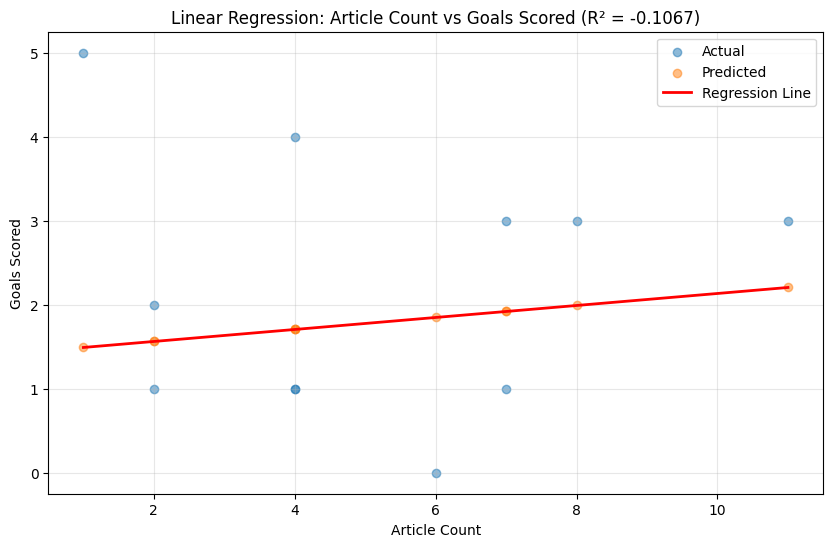

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test_linear[:, 1], y_test, alpha=0.5, label='Actual')
plt.scatter(X_test_linear[:, 1], y_pred_test_linear, alpha=0.5, label='Predicted')

# Plot regression line
x_range = np.linspace(X_test_linear[:, 1].min(), X_test_linear[:, 1].max(), 100)
y_line = weights_linear[0] + weights_linear[1] * x_range
plt.plot(x_range, y_line, 'r-', linewidth=2, label='Regression Line')

plt.xlabel('Article Count')
plt.ylabel('Goals Scored')
plt.title(f'Linear Regression: Article Count vs Goals Scored (R² = {r_squared_linear:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Attempt 2 - Polynomial Regression
#### Creating the Design Matrix

In [18]:
from sklearn.preprocessing import PolynomialFeatures


In [19]:
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X_linear)

print(f"\nPolynomial Features\n")
print(f"Original features: {X_linear.shape[1]}")
print(f"Polynomial features (degree {degree}): {X_poly.shape[1]}")
print(f"Feature names: {poly.get_feature_names_out()}")
print(f"\nFirst 3 rows of polynomial features:")
print(X_poly[:3])


Polynomial Features

Original features: 1
Polynomial features (degree 2): 2
Feature names: ['x0' 'x0^2']

First 3 rows of polynomial features:
[[ 3.  9.]
 [ 5. 25.]
 [ 5. 25.]]


#### Cross Validation

In [20]:
# add bias column
X_poly_with_bias = np.column_stack([np.ones(len(X_poly)), X_poly])

# Split data
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly_with_bias, y, test_size=0.2, random_state=42
)

print(f"\nPolynomial Training set size: {len(X_train_poly)}")
print(f"Polynomial Test set size: {len(X_test_poly)}")
print(f"Features (with bias): {X_train_poly.shape[1]}")

# line of best fit
XtX_poly = np.matmul(X_train_poly.T, X_train_poly)
XtX_inv_poly = np.linalg.inv(XtX_poly)
Xty_poly = np.matmul(X_train_poly.T, y_train_poly)
weights_poly = np.matmul(XtX_inv_poly, Xty_poly)

print(f"\nPolynomial Regression Model\n")
print(f"Model weights: {weights_poly}")
print(f"\nIntercept: {weights_poly[0]:.4f}")
print(f"Linear coefficient: {weights_poly[1]:.4f}")
print(f"Quadratic coefficient: {weights_poly[2]:.4f}")
print(f"\nEquation: goals = {weights_poly[0]:.4f} + {weights_poly[1]:.4f}*x + {weights_poly[2]:.4f}*x²")

# linreg predict to find MSE and R^2 values
y_pred_train_poly = np.matmul(X_train_poly, weights_poly)
y_pred_test_poly = np.matmul(X_test_poly, weights_poly)
# MSE
mse_train_poly = np.mean((y_train_poly - y_pred_train_poly)**2)
mse_test_poly = np.mean((y_test_poly - y_pred_test_poly)**2)
# R²
ss_total_poly = np.sum((y_test_poly - np.mean(y_test_poly))**2)
ss_residual_poly = np.sum((y_test_poly - y_pred_test_poly)**2)
r_squared_poly = 1 - (ss_residual_poly / ss_total_poly)

print(f"\nPolynomial Regression Performance\n")
print(f"Training MSE: {mse_train_poly:.4f}")
print(f"Test MSE: {mse_test_poly:.4f}")
print(f"R² Score: {r_squared_poly:.4f}")

if r_squared_poly > 0:
    print(f"\nThe polynomial model explains {r_squared_poly*100:.2f}% of the variance in goals scored.")
else:
    print(f"\nThe polynomial model performs worse than predicting the mean.")



Polynomial Training set size: 40
Polynomial Test set size: 11
Features (with bias): 3

Polynomial Regression Model

Model weights: [ 1.39081199e+00  8.52485161e-02 -1.06108584e-03]

Intercept: 1.3908
Linear coefficient: 0.0852
Quadratic coefficient: -0.0011

Equation: goals = 1.3908 + 0.0852*x + -0.0011*x²

Polynomial Regression Performance

Training MSE: 1.5585
Test MSE: 2.3899
R² Score: -0.1122

The polynomial model performs worse than predicting the mean.


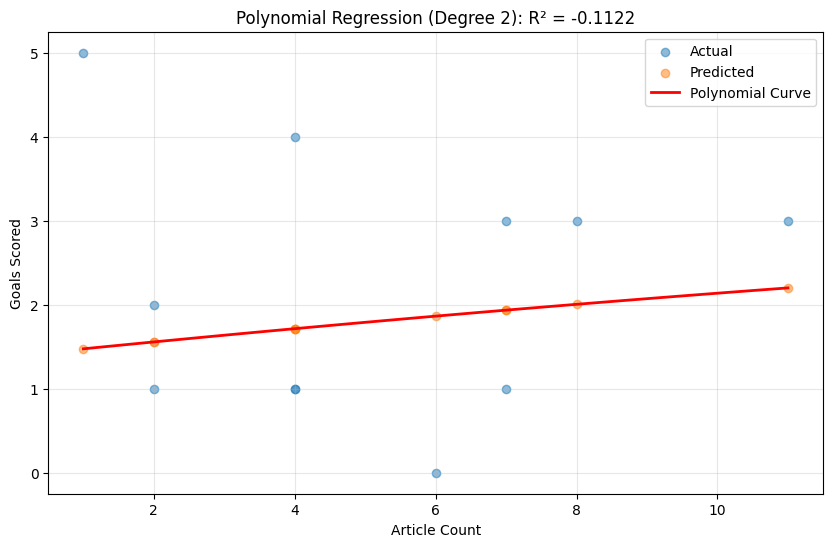

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test_poly[:, 1], y_test_poly, alpha=0.5, label='Actual')
plt.scatter(X_test_poly[:, 1], y_pred_test_poly, alpha=0.5, label='Predicted')

# Plot polynomial curve
x_range = np.linspace(X_test_poly[:, 1].min(), X_test_poly[:, 1].max(), 100)
y_curve = weights_poly[0] + weights_poly[1] * x_range + weights_poly[2] * (x_range ** 2)
plt.plot(x_range, y_curve, 'r-', linewidth=2, label='Polynomial Curve')

plt.xlabel('Article Count')
plt.ylabel('Goals Scored')
plt.title(f'Polynomial Regression (Degree {degree}): R² = {r_squared_poly:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### COMPARISON:

In [22]:
print("MODEL COMPARISON")
print(f"\nLinear Regression:")
print(f"  Test MSE: {mse_test_linear:.4f}")
print(f"  R² Score: {r_squared_linear:.4f}")
print(f"\nPolynomial Regression (Degree 2):")
print(f"  Test MSE: {mse_test_poly:.4f}")
print(f"  R² Score: {r_squared_poly:.4f}")

if r_squared_poly > r_squared_linear:
    print(f"\nPolynomial regression performs better!")
elif r_squared_linear > r_squared_poly:
    print(f"\nLinear regression performs better - the relationship may be linear.")
else:
    print(f"\nBoth models perform similarly.")

MODEL COMPARISON

Linear Regression:
  Test MSE: 2.3781
  R² Score: -0.1067

Polynomial Regression (Degree 2):
  Test MSE: 2.3899
  R² Score: -0.1122

Linear regression performs better - the relationship may be linear.


### Preliminary Results Discussion
Our linear regression analysis shows a lack of relationship between the number of articles from the Guardian written about a team before a game and the Premier League team's amount of goals scored. 

Both the linear and polynomial regression models had negative R squared scores (-0.1067 and -0.1122) which indicates they both predict values worse than simply taking the mean goals scored for all the games. The MSE scores are difficult to interpret without another MSE score for a different feature relationship to compare it to. 

However comparing the 2.37/2.38 linear/polynomial MSE scores to the training MSE scores of 1.5 show that the model performs significantly worse when given new data compared to the data it was trained on. This reinforces that Guardian articles written cannot accurately predict amount of goals scored.

These values imply that there is no meaningful relationship between articles written by the Guardian before a game and the amount of goals a Premier League team will score in a game. 

#### Issues
Our sample size may be too small, since we are only using articles from the Guardian and total articles written across different media could potentially show stronger relationships. 

It would also be interesting to see if there is a stronger relationship between articles written and **home game points scored vs away games**. Additionally, **article word count** would be another feature to compare to see if on average longer articles have a stronger relationship with points scored.

### Ethical Considerations
If there was a stronger relationship here, it could imply that media coverage affected player performance. This would mean that player and audience expectations of the game, perhaps influenced by media coverage, could impact game performance of teams. However, since there was no predictability shown here between articles written in the Guardian and player performance, this does not need to be examined further.

Using article coverage also makes this prediction model work worse on teams that are less known or have smaller fan bases, and therefore less articles are written about them. 

If more media coverage led to higher scores, this could create unfair advantages as more well known teams would be predicted to score more points, which could cause them to become even more well known, and so on.